In [211]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np

import re

import matplotlib.pyplot as plt
from shapely import Point, distance

import osmnx
import contextily as cx

# Preliminares


## Preguntas
Las preguntas a responder son:
1. ¿Quién crea la data, como la crea y en que contexto? 
2. ¿Que fenómenos codifica la data y en que contextos?
3. ¿Quien es el publico o el analista objetivo y cual es el uso objetivo?
4. ¿Que identificadores y atributos están presentes en la data, y cuales no lo están?
5. ¿Que relaciones existen en la data? 
	- Considera los pares identificador/valor y atributo/valor.
	- Considera las relaciones horizontales (relación entre datos que comparten un identificador) y verticales (relación entre datos que comparten un atributo).
	
6. ¿Que realidad constituyen los datos? ¿Quien se beneficia de esta y que realidades alternas eran posibles?
7. ¿Donde hay inestabilidad o fragilidad en la data y sus significados, y que revela esto?
8. ¿Como cambian los significados entre niveles: 
	- Decisiones de codificación,
	- Análisis exploratorio,
	- Interpretación de los datos,
	- Relación con otra data,
	- Los resultados "finales."

## La data

In [212]:
gdf_templosOSM = osmnx.features_from_place(
    query='Community of Madrid',
    tags = {'amenity' : 'place_of_worship'}
)

# Análisis

## 1. Quién crea la data, como la crea y en que contexto

Estos datos provienen de open streetmap (OSM). OSM es una plataforma abierta de datos geospaciales. Estos, y casi todos los datos en OSM, son agregados por voluntarios que tienen algún tipo de conocimiento sobre la zona o los lugares que estan editando. Esto puede ser porque son locales o porque han hecho algún tipo de investigación, como podría ser busquedas en internet, en mapas existentes o en libros de referencía.

Los datos de OSM dependen de sus usuarios, lo cual introduce sesgos y lacgunas. La distribución geografica de los usuarios de OSM y de sus conocimientos no es uniforme. Áreas con mas usuarios tendran mas información local, y áreas mas conocidas tendran mas gente que pueda agregarles información. De igual manera, los tipos de puntos o establecimientos registrados también variara de acuerdo a que tan conocidos o relevantes son. Otra desigualded que existe es en los usuarios de OSM, ya que la mayoría de sus usuarios son hombres. Esto crea lagunas en que lugares frecuentados por mujeres de manera mayoritaria or exclusiva podrián verse menos representados. En los ultimos años, corporaciones también han estado haciendo contribuciones a OSM. Al igual que los usuarios individuales, la información insertada por estos actores corporativos no es uniforme y varia con función de localización y tipo de lugares agregados. A diferencia de los usuarios individuales, la corporaciones son capaces de generar mucha mas información, magnificando sus sesgos en relación con aquellos de los usuarios individuales.

Por ultimo yo también he participado en la creación de esta data con la libreria `osmnx`, la cual descarga datos de OSM, al usar un query que descarte todos los lugares que no esten etiquetados como `place_of_worship` y que no esten localizados dentro de la Comunidad de Madrid.

Dentro de la data de OSM existe el atributo `created_by` y el atributo `source`, al igual que otra información relacionada con la creación de los datos.

In [213]:
# las columnas en esta data que contienen información sobre la creación de los datos

creationDataCols = ['created_by', 'source','source:addr','source:date:addr','source:date:email','source:date:phone',
                    'source:date:url','source:email','source:phone','source:url', 'source:date','source:amenity',
                    'source:date:amenity','source:date:name','source:date:religion','source:name','source:religion','source:wheelchair',
                    'source:date:description', 'source:description','source:geometry', 'building:material', 'source:alt_name:addr',
                    'source:building','source:date:building',  'source:date:denomination', 'source:denomination', 'source:date:opening_hours',
                    'survey:date', 'source:opening_hours', 'source:old_name', 'source:alt_name', 'source:date:alt_name', 'source:fax', 'source:geometry:date']
gdf_sourceData = gdf_templosOSM.copy()[ ['name'] + creationDataCols]
gdf_sourceData

name created_by  \
element id                                                         
node    26261496    Parroquia Nuestra Señora de Luján        NaN   
        145494327                                 NaN        NaN   
        211230234      Capilla de San Ezequiel Moreno       JOSM   
        259650624                                 NaN       JOSM   
        282517177                Ermita de San Isidro        NaN   
...                                               ...        ...   
way     1331437063                       Verbo Divino        NaN   
        1352524450    Parroquia Beata María Ana Mogas        NaN   
        1361469240        Nuestra Señora del Remolino        NaN   
        1389921424                    Salón del Reino        NaN   
        1424654398         Ermita de la Virgen Blanca        NaN   

                                    source             source:addr  \
element id                                                           
node    26261496                       NaN  Ayuntamiento de Madrid   
        145494327                      NaN                     NaN   
        211230234                      NaN                     NaN   
        259650624                      NaN                     NaN   
        282517177                      NaN                     NaN   
...                                    ...                     ...   
way     1331437063                     NaN                     NaN   
        1352524450  Ayuntamiento de Madrid                     NaN   
        1361469240                     NaN                     NaN   
        1389921424                     NaN                     NaN   
        1424654398                     NaN                     NaN   

                   source:date:addr source:date:email source:date:phone  \
element id                                                                
node    26261496         2013-05-01        2013-05-01        2013-05-01   
        145494327               NaN               NaN               NaN   
        211230234               NaN               NaN               NaN   
        259650624               NaN               NaN               NaN   
        282517177               NaN               NaN               NaN   
...                             ...               ...               ...   
way     1331437063              NaN               NaN               NaN   
        1352524450              NaN               NaN               NaN   
        1361469240              NaN               NaN               NaN   
        1389921424              NaN               NaN               NaN   
        1424654398              NaN               NaN               NaN   

                   source:date:url            source:email  \
element id                                                   
node    26261496        2013-05-01  Ayuntamiento de Madrid   
        145494327              NaN                     NaN   
        211230234              NaN                     NaN   
        259650624              NaN                     NaN   
        282517177              NaN                     NaN   
...                            ...                     ...   
way     1331437063             NaN                     NaN   
        1352524450             NaN                     NaN   
        1361469240             NaN                     NaN   
        1389921424             NaN                     NaN   
        1424654398             NaN                     NaN   

                              source:phone  ... source:date:denomination  \
element id                                  ...                            
node    26261496    Ayuntamiento de Madrid  ...                      NaN   
        145494327                      NaN  ...                      NaN   
        211230234                      NaN  ...                      NaN   
        259650624                      NaN  ...                      NaN   
        282517

In [214]:
len(creationDataCols)

35

In [215]:
print(f'{gdf_sourceData.dropna(subset=creationDataCols, how='all').shape[0]} o { 100 - (gdf_sourceData.dropna(subset=creationDataCols, how='all').shape[0] / gdf_sourceData.shape[0] * 100):.4f}% de las filas no tienen ningun valor para las columnas que tienen información sobre la creación de los datos')

531 o 57.8237% de las filas no tienen ningun valor para las columnas que tienen información sobre la creación de los datos


In [250]:
gdf_sourceData.iloc[:, 3:].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1259 entries, ('node', np.int64(26261496)) to ('way', np.int64(1424654398))
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   source:addr                217 non-null    object
 1   source:date:addr           217 non-null    object
 2   source:date:email          47 non-null     object
 3   source:date:phone          268 non-null    object
 4   source:date:url            272 non-null    object
 5   source:email               46 non-null     object
 6   source:phone               267 non-null    object
 7   source:url                 258 non-null    object
 8   source:date                194 non-null    object
 9   source:amenity             22 non-null     object
 10  source:date:amenity        22 non-null     object
 11  source:date:name           39 non-null     object
 12  source:date:religion       21 non-null     object
 13  source:name

Solo 6 filas tienen un valor para `created_by`

In [217]:
gdf_sourceData.dropna(subset='created_by')

name      created_by source  \
element id                                                                      
node    211230234       Capilla de San Ezequiel Moreno            JOSM    NaN   
        259650624                                  NaN            JOSM    NaN   
        309437046  Parroquia Nuestra Señora del Carmen  Potlatch 0.10f    NaN   
        316079411                                  NaN           xybot    NaN   
        330163192                                  NaN  Potlatch 0.10f    NaN   
way     29432871                                   NaN  Potlatch 0.10f    NaN   

                  source:addr source:date:addr source:date:email  \
element id                                                         
node    211230234         NaN              NaN               NaN   
        259650624         NaN              NaN               NaN   
        309437046         NaN              NaN               NaN   
        316079411         NaN              NaN               NaN   
        330163192         NaN              NaN               NaN   
way     29432871          NaN              NaN               NaN   

                  source:date:phone source:date:url source:email source:phone  \
element id                                                                      
node    211230234               NaN             NaN          NaN          NaN   
        259650624               NaN             NaN          NaN          NaN   
        309437046               NaN             NaN          NaN          NaN   
        316079411               NaN             NaN          NaN          NaN   
        330163192               NaN             NaN          NaN          NaN   
way     29432871                NaN             NaN          NaN          NaN   

                   ... source:date:denomination source:denomination  \
element id         ...                                                
node    211230234  ...                      NaN                 NaN   
        259650624  ...                      NaN                 NaN   
        309437046  ...                      NaN                 NaN   
        316079411  ...                      NaN                 NaN   
        330163192  ...                      NaN                 NaN   
way     29432871   ...                      NaN                 NaN   

                  source:date:opening_hours survey:date source:opening_hours  \
element id                                                                     
node    211230234                       NaN         NaN                  NaN   
        259650624                       NaN         NaN                  NaN   
        309437046                       NaN         NaN                  NaN   
        316079411                       NaN         NaN                  NaN   
        330163192                       NaN         NaN                  NaN   
way     29432871                        NaN         NaN                  NaN   

                  source:old_name source:alt_name source:date:alt_name  \
element id                                                               
node    211230234             NaN             NaN                  NaN   
        259650624             NaN             NaN                  NaN   
        309437046             NaN             NaN                  NaN   
        316079411             NaN             NaN                  NaN   
        330163192             NaN             NaN                  NaN   
way     29432871              NaN             NaN                  NaN   

                  source:fax source:geometry:date  
element id                                         
node    211230234        NaN                  NaN  
        259650624        NaN                  NaN  
        309437046        NaN                  NaN  
        316079411        NaN                  NaN  
        330163192        NaN                  NaN  
way     29432871         NaN            

Solo 251 filas tienen información sobre la fuente de la creación de los datos

In [218]:
gdf_sourceData['source'].value_counts()

source
Ayuntamiento de Madrid                                                                                                                                                                  158
PNOA                                                                                                                                                                                     31
survey                                                                                                                                                                                   14
catastro                                                                                                                                                                                  9
Dirección General del Catastro                                                                                                                                                            4
WMS Catastro                                         

Consolidando estas tenemos las siguientes fuentes:

source  count  
Ayuntamiento de Madrid	160  
PNOA	32  
survey	14  
catastro	27  
conocimiento local	5  
GPS	3  
imagenes aereas	2  
Bing	2  
Instituto Geográfico Nacional	2  
https://twitter.com/SecretosdeMadri/status/514710846774448128	1  
es:Iglesia de San Antonio de los Alemanes	1  
http://www.romanul.eu/patriarhul-bisericii-ortodoxe-a-ajuns-la-madrid/	1  
streetlevel imagery	1  
http://episcopiaspanieiportugaliei.es/parohii-ortodoxe-romane-spania	1  
IDEE	1  
Minitsrio de Cultura	1  
Vista in-situ	1  
Nomecalles	1  
knowledge	1  


Análisando estas dos columnas vemos que no hay información sobre quién creo la data para la mayoría de los puntos. También tenemos poca información sobre la fuente de esta información. Esto crea ambiguedad e incertidumbre sobre los datos. Adicionalmente, la variedad de fuentes de datos introduce instabilidad en cuanto a la calidad de la información. Dentro de los datos para los que conocemos la fuente de la información, aquellos que vienen de datos de el ayuntamiento de madrid forman la categoria mas grande. Para aquellos que fueron generados a partir de imagenes aereas (incluyendo PNOA) o GPS, hay cierta incertidumbre sobre la localización exacta de los lugares. Por otro lado, cada una de estas fuentes puede dar coordenadas con niveles variantes de precision y exactitud. 

Solo 217 filas tienen información sobre la fuente de datos de la dirección. Todos menos uno de estos viene del ayuntamiento de madrid

In [219]:
gdf_sourceData['source:addr'].value_counts()

source:addr
Ayuntamiento de Madrid    216
phone_survey                1
Name: count, dtype: int64

La mayoria de filas no tienen información de cuando fueron creados, pero do los que si, la mayoria fueron creados el mismo día : 1 mayo 2013

In [220]:
gdf_sourceData['source:date'].value_counts()

source:date
2013-05-01    148
2014           11
2010           10
2009            9
2016-01         4
2023-05-06      3
30-12-2016      3
2015-01         2
2011            2
2008            1
2022-01         1
Name: count, dtype: int64

Como podemos ver, las filas con datos de fuente se encuentran dentro de los limites de el ayuntamiento de Madrid

/tmp/ipykernel_42367/4146075343.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


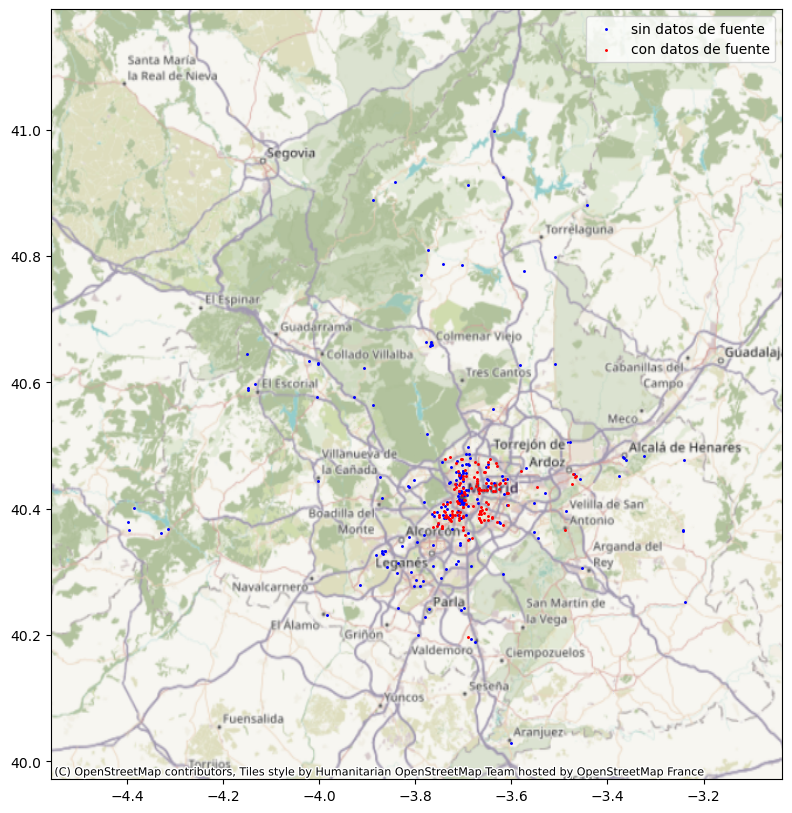

In [221]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_templosOSM[gdf_templosOSM['source'].isna()].plot(markersize=5, marker='.', color='blue', ax = ax, label='sin datos de fuente')
gdf_templosOSM[~gdf_templosOSM['source'].isna()].plot(markersize=5, marker='.', color='red', ax = ax, label='con datos de fuente')

ax.legend()

cx.add_basemap(crs=gdf_templosOSM.crs, ax = ax)

## 2. Que fenomoneos estan codificados?

Este dataset codifica las localizaciones de centros religiosos dentro de la comunidad de Madrid.

## 3. Cual es el publico objetivo y el uso objetivo?

OSM existe para dar una alternativa abierta a mapas privados como son los de Google o Apple, y a plataformas que quieran crear sus propias alternativas. El publico objetivo principal de OSM es el público en general, o, de manera mas precisa, cualquiér persona que quiera navegar de un lugar a otro o que quiéra saber donde se encuentra algun lugar en particular. OSM tiene dos vías para llegar a este público. La primera es su propía plataforma y la segunda son aquellos que usan los datos de OSM dentro de otra plataforma de mapas. OSM también es usado por investigadores que quiéran recolectar información sobre la locallización de POIS. De este modo identificamos tres públicos objetivos: navegadores, desarolladores de mapas o aplicaciones terceras e investigadores. También tenemos tres usos objetivos relacionados: navegación, localización de lugares e investigación.

## 4. ¿Que identificadores y atributos están presentes en la data, y cuales no lo están?

Cada dato en esta data tiene como identificador un numero unico, y cada identificador identifica a un templo. 

Aparte de los atributos que indicán de donde o cuando fueron insertados otros datos, hay 116 atribtuos en la data.

In [222]:
gdf_templosDesc = gdf_templosOSM.copy()
gdf_templosDesc = gdf_templosDesc.drop(creationDataCols, axis=1)
gdf_templosDesc.shape[1]

112

In [223]:
np.max(np.unique_counts([i[1] for i in gdf_templosDesc.index.to_list()])[1])

np.int64(1)

In [224]:
columns = gdf_templosDesc.columns.to_list()

16 de estas columnas contienen el nombre de el templo en diferentes idiomas. Existen dos campos que saltan a la vista: `name:signed` y `named:1959`. para ambos, solo existe un par atributo/valor. `name:1959` indica un nombre historico. En concreto, este dato codifica el nombre historico de la ahora Basilica de Santa Cruz del Valle de Cuelgamuros. Los idiomas que estos atributos representan son: ingles, español, rumano, ukraniano, gales, aleman, chino, koreano, frances, italiano, polaco y portuges. El atributo `name` vendria a representar el nombre "real" - ya que no tiene ningun modificador - mientras que los otros campos vendrian a ser traducciones.  

In [225]:
r = re.compile("(name)")
nameList = list(filter(r.match, columns))
print(len(nameList) , '\n', nameList)

16 
 ['name', 'name:en', 'name:es', 'name:ro', 'name:uk', 'name:gl', 'name:de', 'name:zh', 'name:signed', 'name:ko', 'name:fi', 'name:fr', 'name:it', 'name:pl', 'name:pt', 'name:1959']


De los 1259 identificadores totales en la data, solo 1145 cuentan con un par `atributo/valor` asociado para el atributo `name`. De manera similar, solo existen 11 y 12 pares `atributo/valor` para los atributos `name:en` y `name:es` respectivamente.

In [226]:
gdf_templosDesc[nameList].info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1259 entries, ('node', np.int64(26261496)) to ('way', np.int64(1424654398))
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         1145 non-null   object
 1   name:en      11 non-null     object
 2   name:es      12 non-null     object
 3   name:ro      4 non-null      object
 4   name:uk      1 non-null      object
 5   name:gl      3 non-null      object
 6   name:de      1 non-null      object
 7   name:zh      1 non-null      object
 8   name:signed  1 non-null      object
 9   name:ko      1 non-null      object
 10  name:fi      1 non-null      object
 11  name:fr      1 non-null      object
 12  name:it      1 non-null      object
 13  name:pl      1 non-null      object
 14  name:pt      1 non-null      object
 15  name:1959    1 non-null      object
dtypes: object(16)
memory usage: 204.6+ KB


In [227]:
gdf_templosDesc[~gdf_templosDesc['name:signed'].isna()][['name', 'name:signed']]

,,name,name:signed
element,id,,
way,873186924,NaN,no


In [228]:
gdf_templosDesc[~gdf_templosDesc['name:gl'].isna()][['name', 'name:gl']]

name  \
element id                                                 
way     176983935     Iglesia de Nuestra Señora del Aire   
        258464886   Parroquia de la Virgen de los Llanos   
        1133453299    Catedral Ortodoxa Rumana en Madrid   

                                                 name:gl  
element id                                                
way     176983935          Igrexa da Nosa Señora do Aire  
        258464886              Igrexa da Virxe dos Chans  
        1133453299  Catedral Ortodoxa Romanesa en Madrid

Los pares atributo/valor que tienen de atributo `wikidata`, `wikimedia_commons`, `wikipedia` o `operator:wikidata` codifican información sobre como el identificador del dato respectivo se relaciona a datos dentro de las varias bases de datos de la Fundación Wikimedia que codifican el mismo fenomeno, o un fenomeno relacionado de manera sinecdoquica. En estos pares, el valor es el representamen de los signos en esta data externa; es decir, estos signos hacen referencía a otros signos. Este es un ejemplo de como on dato y la data a la que pertenece tienen significado al relacionarse con otra data. También son evidencía de porque una lectura exhaustiva de los datos es imposible, ya que los signos pueden conectar a otros signos cuya lectura exhaustiva sería necesaria para completar la lectura inicial.  

In [229]:
r = re.compile(".*(wiki).*")
wikiList = list(filter(r.match, columns))
print(len(wikiList) , '\n', wikiList)

4 
 ['wikidata', 'wikimedia_commons', 'wikipedia', 'operator:wikidata']


In [230]:
gdf_templosDesc[wikiList].info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1259 entries, ('node', np.int64(26261496)) to ('way', np.int64(1424654398))
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   wikidata           233 non-null    object
 1   wikimedia_commons  25 non-null     object
 2   wikipedia          121 non-null    object
 3   operator:wikidata  1 non-null      object
dtypes: object(4)
memory usage: 86.6+ KB


In [231]:
gdf_templosDesc[~gdf_templosDesc['wikidata'].isna()][['name'] + wikiList]

name  \
element id                                                              
node    309437046                 Parroquia Nuestra Señora del Carmen   
        313346888                    Convento de Carmelitas Descalzas   
        1097116650                        Santo Domingo de la Calzada   
        1517405738                             Iglesia de San Lorenzo   
        3163832754            Capilla de Nuestra Señora de la Soledad   
...                                                               ...   
way     1082576294                    Parroquia San Lucas Evangelista   
        1144478506           Iglesia de Nuestra Señora de la Asunción   
        1195178089             Iglesia de Nuestra Señora de Covadonga   
        1253287073             Basílica de San Lorenzo de El Escorial   
        1270426081  Iglesia del Monasterio de Benedictinas de San ...   

                     wikidata  \
element id                      
node    309437046   Q48815797   
        313346888   Q25174799   
        1097116650  Q26195961   
        1517405738   Q5910638   
        3163832754  Q28922479   
...                       ...   
way     1082576294  Q65620031   
        1144478506  Q48131606   
        1195178089  Q55743906   
        1253287073   Q8243751   
        1270426081   Q5166190   

                                                    wikimedia_commons  \
element id                                                              
node    309437046                                                 NaN   
        313346888   Category:Convento del Sagrado Corazón y Nuestr...   
        1097116650                                                NaN   
        1517405738                                                NaN   
        3163832754                                                NaN   
...                                                               ...   
way     1082576294  Category:Iglesia nueva de San Lucas, Villanuev...   
        1144478506                                                NaN   
        1195178089                                                NaN   
        1253287073                                                NaN   
        1270426081                                                NaN   

                                                            wikipedia  \
element id                                                              
node    309437046                                                 NaN   
        313346888   es:Convento del Sagrado Corazón y Nuestra Seño...   
        1097116650          es:Capilla de Santo Domingo de la Calzada   
        1517405738                 es:Iglesia de San Lorenzo (Madrid)   
        3163832754     es:Humilladero de Nuestra Señora de la Soledad   
...                                                               ...   
way     1082576294                                                NaN   
        1144478506                                                NaN   
        1195178089                                                NaN   
        1253287073     es:Real Basílica de San Lorenzo de El Escorial   
        1270426081                es:Convento de San Plácido (Madrid)   

                   operator:wikidata  
element id                            
node    309437046                NaN  
        313346888                NaN  
        1097116650               NaN  
        1517405738               NaN  
        3163832754               NaN  
...                              ...  
way     1082576294               NaN  
        1144478506               NaN  
        1195178089               NaN  
        1253287073               NaN  
        1270426081               NaN  

[233 rows x 5 columns]

In [232]:
gdf_templosDesc[~gdf_templosDesc['operator:wikidata'].isna()][['name', 'operator:wikidata']]

,,name,operator:wikidata
element,id,,
node,12954313209,NaN,Q1781570


Los atributos `historic` y `heritage` representan conceptos similares, pero sus diferencias, instabilidad y omisiones reflejan la sujetividad y construcción de la data. Empezando con el atributo `historic`, este codifica si un lugar en OSM es un lugar historico, y si lo es se le releciona con un valor que indique que tipo de lugar es. En esta data, hay cinco pares atributo/valor con el atributo `historic`. Los valores que correspondientes son "church", "monastery" y "ruins" con el primero apareciendo en tres pares. El atributo `historic` refleja la sujetividad y la construcción de la data. Para empezar, el signo "historico" no tiene un significado estable. Dependiendo del contexto, el objeto o de los observadores, un objeto puede considerarse historico o no. Un objeto se considera histórico tras cierto tiempo, pero la duración requerida varía según el contexto político, espacial o social. Esta misma data refleja la inestabilidad del significado de los "historico," ya que el dato `(4579328727, historic) : church` califica a esta iglesia como historica. Este dato esta relacionado con otro que nos da el nombre de la iglesia, lo cual nos permite encontrar su material online https://iglesiaverbodedios.com/nosotros/, en el que dicen que han existido por 20 años. Haciendo referencía a un objeto que ya hemos explorado, la Basilica en el Valle de Cuelgamuros no esta relacionado con el atributo `historic` a pesar de haber existido por mas the 20 años; un hecho que la data codifica ya que existe una relación entre esta basílica y el atributo `name:1959`.

Por otro lado, los datos con el atributo `hertitage` https://wiki.openstreetmap.org/wiki/Key:heritage tienen como objeto quién ha denominado el lugar como patrimonio cultural. El atributo puede estar relacionado a un valor numerico del 1 al 10, el cual codifica que nivel administrativo ha hecho la designación. https://wiki.openstreetmap.org/wiki/Key:admin_level OSM usa valores numericos para facilitar consistencia que no sería posible si se usaran los nombres oficiales de los niveles administrativos usados por el mundo (e.g. un país podria usar el termino estado y otro provincia para el mismo nivel de administración). En otras palabras, reconociendo que muchos representámenes representán el mismo objeto, que conversamente un representámen tiene varios objetos dependiendo del observador y que esto genera cambios en el interpretamen, OSM ha optado por un signo propoio para cada nivel administrativo que puede servir universalmente para todos los usuarios. En esta columna encontramos mas de la inestabilidad de la data. Por un lado, el atributo `heritage` enfatiza que la data tiene varios publicos objetivos. Al usar un signo que no tiene un significado obvio - es necesario saber que 2 es el nivel de administración nacional y 10 el nivel de administración mas local, y ademas se debe saber la herarquía de todos los niveles administrativos del pais en el que el lugar se ubica - se ve que el publico objetivo de este atributo no es un publico general tratando de navegar hacia una localización. Mirando a la columna entera, notamos que solo tiene tres datos, sin embargo podemos nombrar por lo menos un otro identificador (La Basilica del Valle de Cuelgamuros) en la data que representa una iglesia que ha sido declarada patrimonio, pero que no tiene un dato con el atributo `heritage`.Finalmente, los tres datos con atributo `heritage` estan relacionados horizontalmente con un dato correspondiente con el atributo `heritage:operator`. Los valores relacionados con este atributo codifica que entidad en concreto ha hecho la declaración del lugar como patrimonio. Por ejemplo, mientras que el dato `(28702618, heritage) : 2` nos dice que ha sido por una adminstración nacional, el dato `(28702618, heritage:operator) : bic` codifica que ha sido declarado como patrimonio al ser parte del registro de Bienes de Interes Cultural. 

Los atributos `heritage` y `historic` demuestran que la data no es neutral, ya que son el producto de decisiones sobre que codificar y como. En el caso de el atributo `heritage` se podria decir que la omisión de un dato para la Basílica del Valle de Cuelgamuros es simplemente un error o una falta de datos, pero en el caso de del atributo `historic` vemos como tanto la inclusión como la omisión podrían ser correctas dependiendo del interpretamen que tenga el signo "hisotric" para quien este creando la data. “Así, `historic` y `heritage` no son categorías neutrales: son signos cuya relación entre representamen, objeto e interpretamen varía según el observador, revelando cómo OSM cristaliza decisiones ideológicas sobre qué es ‘histórico’ y qué cuenta como patrimonio.”

In [233]:
gdf_templosDesc[~gdf_templosDesc['heritage'].isna()][['name','heritage', 'historic', 'heritage:operator']]

name  \
element id                                                              
way     28702618             Real Basílica de San Francisco el Grande   
        1253287073             Basílica de San Lorenzo de El Escorial   
        1270426081  Iglesia del Monasterio de Benedictinas de San ...   

                   heritage historic heritage:operator  
element id                                              
way     28702618          2      NaN               bic  
        1253287073        1      NaN               whc  
        1270426081        6   church               MCD

In [234]:
gdf_templosDesc[~gdf_templosDesc['historic'].isna()][['name', 'heritage', 'historic', 'heritage:operator']]

name  \
element  id                                                              
node     4579328727                    Iglesia de Dios (Verbo de Dios)   
         4642655822                    Iglesia de Los Elegidos de Dios   
relation 2336342                 Convento de las Trinitarias Descalzas   
way      1176540098  Espadaña en ruinas de la Iglesia de Santo Domingo   
         1270426081  Iglesia del Monasterio de Benedictinas de San ...   

                    heritage   historic heritage:operator  
element  id                                                
node     4579328727      NaN     church               NaN  
         4642655822      NaN     church               NaN  
relation 2336342         NaN  monastery               NaN  
way      1176540098      NaN      ruins               NaN  
         1270426081        6     church               MCD

Los dos atributos principales que le dan significado a esta data son los atributos `amenity` y `geometry`. Esta data fue creada a partir de la data creada por OSM, seleccionando solo aquellas filas que tienen al valor "place_of_worship" relacionado con el atributo `amenity` y cuyo valor relacionado con el atributo `geometry` se encontrara dentro de la geometría que representa la Comunidad de Madrid en un mapa político. El atributo `amenity` codifica qué tipo de lugar el identificador es. En el caso de esta data, todos los datos en la columna del atributo `amenity` tienen el valor "place_of_worship".

El atributo `geometry` codifica la geometría de cada identificador, que puede ser como un Punto o un Polígono, en el sistema de referencias de coordenadas (CRS) EPSG:4326. Dentro de esta columna existe una relación entre datos que tienen valores idénticos, ya que podrían estar significando el mismo lugar o múltiples lugares que comparten un espacio físico. Similarmente, hay una relación dentro de la columna entre datos que tienen valores codificados como puntos y los que tienen valores codificados como polígonos, ya que un punto podría encontrarse dentro de uno o más polígonos. El analista tendrá que decidir cómo resolver estas relaciones, ya que su significado es ambiguo y cómo se resuelvan influye en qué realidad construye la data. Mirando a los datos con los que estos datos de geometría están relacionados horizontalmente —es decir, comparten un identificador— podría aclarar el significado o ayudar al analista a tomar una decisión, pero, ultimamente, esta será subjetiva.

Por ejemplo, una misma iglesia podría estar codificada como un punto en un dato y como un polígono en otro. El valor del primer dato se encontraría espacialmente dentro del valor del segundo, y el analista tendría que decidir qué hacer con esos datos. El analista podría decidir recurrir a una realidad externa, en la cual podría ver si existen dos iglesias en el mismo lugar o si los dos datos están codificando el mismo objeto con representámenes diferentes. En el primer caso, decidiría no modificar los datos. En el segundo, tendría que decidir si quiere que la data construya una realidad en la que hay dos iglesias en un mismo lugar, o si quiere que la data refleje la realidad externa de que hay solamente una. Si decide a favor de crear una realidad más "correcta", tendría que decidir cuál de los datos conservar. En este punto tendría que preguntarse qué es más útil para su análisis, puntos o polígonos. Si decide en puntos, tendría que decidir si utlizara el valor codificado como punto que ya tiene, o si reducira el polígono a un punto dentro de si. En este ejemplo vemos la inestabilidad del significado de la data, y empezamos a ver indicios de cómo el analista influye en el significado que la data tiene; que ni el analista, ni la data, ni el análisis son agentes inocentes.

El atributo `religion` codifica a qué religión pertenece el templo que la fila representa. Este atributo refleja decisiones políticas sobre qué se considera una religión. Por ejemplo, el par `religion / christian` es el mismo signo usado para codificar la religión de todos los templos que caen bajo una definición amplia de "cristianidad." Es decir, aplana todas las identidades que existen bajo esta categoría. Los datos en la columna `religion` pueden estar relacionados horizontalmente con datos en la columna `denomination`, la cual sí considera diferencias entre sectas como Testigos de Jehová y Católicos o Shia y Sunni. Sin embargo, vemos que cerca del 25% de identificadores en la data no tienen una relación con un par atributo / valor para el atributo `denomination`, mientras que solo 1.3% de los identificadores no tienen una relación con un par atributo / valor para el atributo `religion`. Mirando más de cerca, vemos que la falta de valores relacionados con el atributo `denomination` no está distribuida uniformemente entre las religiones codificadas en la data. La mayoría de los valores en la columna `denomination` codifican sectas cristianas. Por otro lado, el único templo judío en la data no tiene un valor correspondiente para `denomination`, y de los 23 templos musulmanes en la data, solo 7 tienen su secta codificada. Todo esto resalta la inestabilidad de la data y la realidad que esta construye a partir de las decisiones tomadas a la hora de crear la data. Esta data crea un mundo en el que los templos cristianos de Madrid son ideológicamente diversos, mientras que los templos de otras religiones no lo son. Esta realidad existe independientemente de la realidad externa y, si fuera usada en un análisis, reproduciría conclusiones que no serían neutrales, incluso si el resto del proceso de análisis lograra serlo.

In [235]:
print(gdf_templosOSM.loc[:, ['religion']].value_counts(dropna=False, normalize=True))
print('\n'+ '-' * 100 + '\n')
print(gdf_templosOSM.loc[:, ['denomination']].value_counts(dropna=False, normalize=True))

religion     
christian        0.959492
muslim           0.018268
NaN              0.012708
buddhist         0.002383
NO?              0.000794
hare_krishna     0.000794
bahai            0.000794
multifaith       0.000794
jewish           0.000794
none             0.000794
scientologist    0.000794
sikh             0.000794
taoist           0.000794
Name: proportion, dtype: float64

----------------------------------------------------------------------------------------------------

denomination         
roman_catholic           0.440032
NaN                      0.247816
catholic                 0.196982
evangelical              0.041303
jehovahs_witness         0.024623
baptist                  0.009531
seventh_day_adventist    0.009531
sunni                    0.005560
latter_day_saints        0.003971
orthodox                 0.003971
romanian_orthodox        0.003971
anglican                 0.003177
new_apostolic            0.001589
pentecostal              0.001589
evangelic     

In [236]:
gdf_templosOSM.loc[:, ['denomination', 'religion']].value_counts(dropna=False, normalize=False).sort_index(level=0, ascending=False)

denomination           religion     
NaN                    NaN               14
                       taoist             1
                       sikh               1
                       scientologist      1
                       none               1
                       muslim            16
                       multifaith         1
                       jewish             1
                       hare_krishna       1
                       christian        271
                       buddhist           2
                       bahai              1
                       NO?                1
theravada              buddhist           1
sunni                  muslim             7
seventh_day_adventist  christian         12
romanian_orthodox      christian          5
roman_catholic         NaN                1
                       christian        553
protestant             christian          1
presbyterian           christian          1
pentecostal            christian       

Otros atributos presentes en el dataset son aquellos que codifican información de contacto (e.g. `email`, `phone`, `fax`, etc.) o los que codifican información de materiales online sobre el lugar (e.j. `wikidata`, `url`, `website`, etc.). Estos tipos de atributos implican un público objetivo que este interesado en obtener información mas ayá de la que puede proporcionar un mapa. La data también contiene el atributo `wheelchair` que indica si un lugar es accesible para personas en sillas de ruedas. En este dataset en particular, solo existen 95 pares Atributo / Valor para este atributo. Los valores posibles son "yes", "no" y "limited" por lo cual la ausencia de datos con este atributo para el resto de identificadores resulta ambigua; no se puede decidir con certeza que la omisión del dato implica la omisión de infraestructura accesible. La data también contiene atributos que codifican si el lugar esta en ruinas, si es un lugar turistico, el color de la casa, si es un lugar seguro para personas lgbti https://wiki.openstreetmap.org/wiki/Proposal:Lgbtq:unmarked_tag y muchos otros mas. Como ya hemos visto, los datos en una data no solo codifican información, sino que codifican supuestos y decisiones sobre que información se debe codificar y como. Por lo tanto, cualquier análisis que use datos cargara esta historia. Como ya hemos visto, el significado de los datos no esta determinado a la hora de crearlos, sino que se vera influenciado por el análista y por el análisis propío. Volveremos a ver esto a través del análisis exploratorio y del análisis en su totalidad,

In [237]:
contactCols = ['phone', 'phone_1', 'contact:phone', 'website', 'contact:website', 'url', 'email', 'email:1', 'contact:email', 'contact:email_1', 'contact:instagram', 'fax']
gdf_templosDesc[contactCols].info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1259 entries, ('node', np.int64(26261496)) to ('way', np.int64(1424654398))
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   phone              419 non-null    object
 1   phone_1            1 non-null      object
 2   contact:phone      5 non-null      object
 3   website            95 non-null     object
 4   contact:website    3 non-null      object
 5   url                413 non-null    object
 6   email              91 non-null     object
 7   email:1            1 non-null      object
 8   contact:email      4 non-null      object
 9   contact:email_1    1 non-null      object
 10  contact:instagram  1 non-null      object
 11  fax                2 non-null      object
dtypes: object(12)
memory usage: 165.3+ KB


In [238]:
gdf_templosDesc[['wheelchair']].value_counts(dropna=False)

wheelchair
NaN           1164
yes             54
no              28
limited         13
Name: count, dtype: int64

In [239]:
gdf_templosDesc[~gdf_templosDesc['fixme'].isna()][['name', 'fixme', 'geometry', 'religion']]

,,name,fixme,geometry,religion
element,id,,,,
node,8950850575,NaN,exact placement,POINT (-3.56998 40.46378),christian


In [240]:
gdf_templosDesc.dropna(subset=['destroyed:building', 'ruins', 'abandoned'], how='all')[['name', 'geometry', 'destroyed:building', 'ruins', 'abandoned']]

name  \
element id                                                              
way     913605210   Parroquia Virgen de la Paloma y San Pedro el Real   
        1093335412                                                NaN   

                                                             geometry  \
element id                                                              
way     913605210   POLYGON ((-3.71143 40.40825, -3.7114 40.40837,...   
        1093335412  POLYGON ((-3.77371 40.38418, -3.77367 40.38412...   

                   destroyed:building ruins abandoned  
element id                                             
way     913605210              church   yes       NaN  
        1093335412                NaN   NaN       yes

In [241]:
gdf_templosDesc[~gdf_templosDesc['tourism'].isna()][['name', 'tourism', 'geometry', 'religion']]

name  \
element  id                                                           
relation 531354              Monasterio de Santa María de El Paular   
         2336342              Convento de las Trinitarias Descalzas   
         5575752     Catedral-Magistral Santos Niños Justo y Pastor   
         5781499                         Real Iglesia de San Andrés   
         6083719                                 Iglesia de Alpajés   
         8834329                        Convento del Corpus Christi   
way      28702618          Real Basílica de San Francisco el Grande   
         32897827                        Parroquia de Santa Bárbara   
         86627568                           Colegiata de San Isidro   
         154205964                                 Santiago Apóstol   
         235204491                           Iglesia de San Antonio   
         296768316               Ermita del Cristo de los Doctrinos   
         577853686                   Parroquia San Jerónimo el Real   
         1002779501             Ermita de San Antonio de la Florida   

                        tourism  \
element  id                       
relation 531354          museum   
         2336342     attraction   
         5575752     attraction   
         5781499     attraction   
         6083719     attraction   
         8834329     attraction   
way      28702618    attraction   
         32897827    attraction   
         86627568    attraction   
         154205964   attraction   
         235204491   attraction   
         296768316   attraction   
         577853686   attraction   
         1002779501  attraction   

                                                              geometry  \
element  id                                                              
relation 531354      POLYGON ((-3.88883 40.88846, -3.88855 40.88829...   
         2336342     POLYGON ((-3.69771 40.4137, -3.69757 40.4137, ...   
         5575752     POLYGON ((-3.36932 40.4806, -3.36932 40.48061,...   
         5781499     POLYGON ((-3.71138 40.41224, -3.71135 40.41216...   
         6083719     POLYGON ((-3.59837 40.03589, -3.59837 40.03593...   
         8834329     POLYGON ((-3.35946 40.48202, -3.35966 40.482, ...   
way      28702618    POLYGON ((-3.71482 40.41042, -3.71483 40.41045...   
         32897827    POLYGON ((-3.69371 40.42448, -3.69374 40.42438...   
         86627568    POLYGON ((-3.70741 40.41283, -3.70738 40.41299...   
         154205964   POLYGON ((-4.01715 40.56061, -4.01705 40.56061...   
         235204491   POLYGON ((-3.60581 40.03349, -3.60579 40.03348...   
         296768316   POLYGON ((-3.36027 40.48184, -3.3603 40.48198,...   
         577853686   POLYGON ((-3.69126 40.4146, -3.69083 40.4146, ...   
         1002779501  POLYGON ((-3.72603 40.42571, -3.72608 40.42576...   

                      religion  
element  id                     
relation 531354      christian  
         2336342     christian  
         5575752     christian  
         5781499     christian  
         6083719     christian  
         8834329     christian  
way      28702618    christian  
         32897827    christian  
         86627568    christian  
         154205964   christian  
         235204491   christian  
         296768316   christian  
         577853686   christian  
         1002779501  christian

In [242]:
gdf_templosDesc.dropna(subset=['fence_type', 'building:colour', 'roof:material', 'barrier'], how='all')[['fence_type', 'barrier', 'building:colour', 'roof:material']]

fence_type barrier building:colour roof:material
element  id                                                         
relation 2745412           NaN     NaN         #B29E93           NaN
way      28668631          NaN   fence             NaN           NaN
         30676702          NaN   fence             NaN           NaN
         170265197         NaN   fence             NaN           NaN
         200038007         NaN   fence             NaN           NaN
         204580200         NaN   fence             NaN           NaN
         224644778         NaN    wall             NaN           NaN
         229194752         NaN     NaN            gray           NaN
         232042163         NaN   fence             NaN           NaN
         256399971         NaN   fence             NaN           NaN
         1033335308        NaN     NaN         #AFA596    roof_tiles
         1163388851      metal     NaN             NaN           NaN
         1253287073        NaN     NaN         #E3CFC6           NaN

In [243]:
gdf_templosDesc.drop(nameList + wikiList + contactCols + 
                     ['alt_name', 'old_name', 'heritage', 'heritage:operator', 'historic', 
                      'geometry', 'amenity', 'denomination', 'religion'], 
                      axis=1).columns

Index(['community', 'addr:city', 'addr:postcode', 'check_date',
       'addr:housenumber', 'addr:street', 'opening_hours', 'service_times',
       'wheelchair', 'building', 'addr:country', 'note', 'lgbtq',
       'addr:housename', 'addr:subdistrict', 'loc_name', 'addr:unit', 'office',
       'wheelchair:description', 'description', 'addr:ward', 'addr:district',
       'addr:province', 'access', 'fixme', 'level', 'air_conditioning',
       'polling_station', 'building:part', 'operator', 'protection_title',
       'ref:bic', 'designation', 'place_of_worship', 'building:levels',
       'start_date', 'barrier', 'tourism', 'height', 'layer',
       'building:architecture', 'addr:suburb', 'roof:shape', 'mapillary',
       'lit', 'disused:building', 'nohousenumber',
       'building:levels:underground', 'image', 'landuse', 'addr:place',
       'roof:colour', 'internet_access', 'destroyed:building', 'ruins',
       'abandoned', 'ruined', 'fence_type', 'area', 'man_made', 'tower:type',
       '

## 5. Que relaciones existen entre los datos?

Los datos `(8387952, name:1959) : Basílica del Valle de los Caídos` y `(8387952, name) : Basílica de Santa Cruz del Valle de los Caídos` muestran una relación horizontal que refleja cambios temporales en el nombre del templo que codifican. El par `name:1959 / Basílica del Valle de los Caídos` liga el lugar al discurso franquista del "Valle de los Caídos" mientras que el par `name / Basílica de Santa Cruz del Valle de los Caídos` intenta reinscirbirlo bajo la logica litúrgica al incluier los signos "Santa Cruz". La inclusión de "Valle de los Caídos" en ambos pares muestra que el lugar al que ambos nombres representan no logra desprendersa de la marca conflictiva. La propia basílica, que en su material online opta por “Basílica del Valle de los Caídos”, complica aún más la relación, al igual que Google Maps, que la designa “Iglesia Abacial de Santa Cruz en el Valle de Cuelgamuros”. Esto alza preguntas sobre porque la inclusión de "Santa Cruz" y de que si hay un desvio en el nombre, porque conservar "Valle de los Caidos" en el nombre en vez de cambiarlo al nombre oficial de "Valle de Cuelgamuros". Adicionalmente, la data no resuelve el conflicto, sino que al mantener ambos nombres en paralelo resalta la escisión interna del significante. El dato `(8387952, name) : Basílica de Santa Cruz del Valle de los Caídos` se encuentra deslizándose entre memorias y discursos sin poder fijarse, y la relación horizontal entre los dos datos expone este deslizamiento.

Podemos también explorar la relación horizontal de los datos que diferen en los atributos de nombre para diferentes lenguajes. Por ejemplo, podemos ver que hay pocas filas - es decir, todos los datos que comparten una relación horizontal - que tienen datos con atributos `name` y `name:es`. El atributo `name` implica un nombre considerado "real" en OSM, mientras que las otras implican traducciones. Vemos que para la mayoria de filas en la data el nombre en español es el "real" y no ven necesario especificar en que idioma esta. Esto ultimo también nos dice que el publico objetivo es aquél que entendería español. Tornando nuestra atención hacía aquellos que si tienen ambos atributos, notamos que hay varios valores para `name` que estan en rumano, con el atributo `name:es` mostrando la traducción al español. En cuatro casos, estas filas para cual el nombre "real" es rumano también incluyen el mismo nombre como valor para el atributo `name:ro`. Estas filas corresponden a templos Ortodoxo Rumanos. Si comparamos esto con las once filas con un valor en `name:en`, el valor para `name` esta en español. De hecho este es el caso para todas las filas que tienen un valor para los atributos de nombres en un lenguaje que no sea el español, except en aquellas que tienen un valor para `name:ro`. Por otro lado, el atributo `name` no esta determinado por el nombre "real" de el templo. Ya hemos visto el ejemplo de la Basílica en el Valle de Cuelgamuros, pero también podemos ver esto en el dato `(2336342, name) : Convento de las Trinitarias Descalzas` que codifica el nombre de un templo cuyo nombre oficial es "El monasterio de San Ildefonso y San Juan de Mata."  Es decir, el atributo `name` es el nombre "real" el cual es determinado por quienes esten buscando el templo y que idioma hablen, y de por que nombres se conoce el templo. Por otro lado, los atributos que especifican en que idioma esta el nombre estan para dar información adicional para aquellos que no formen parte del público objetivo. De esta forma, la data no solo refleja para quién es el templo que codifica, sino que también para quien esta destinada la data misma.

In [176]:
gdf_templosDesc[~gdf_templosDesc['name:es'].isna()][['name', 'name:es', 'name:ro', 'geometry']]

name  \
element  id                                                              
node     2921549125           Iglesia Fraternidad Cristiana Vida Nueva   
         4033545926  Parohia Ortodoxă Română „Sfântul Ierarh Nectar...   
         4114350442               Catedrala Ortodoxă Română din Madrid   
         4434892489                    Iglesia Evangélica de Trafalgar   
         4510349757  Testigos Cristianos de Jehová. Calle Doctor Gó...   
         4571357789                            Parroquia San Fortunato   
         6597661087          Salón del Reino de los Testigos de Jehová   
relation 4051685     Catedral de Nuestra Señora del Pilar de Justo ...   
         5575752        Catedral-Magistral Santos Niños Justo y Pastor   
         8834329                           Convento del Corpus Christi   
way      473139731                          Iglesia Evangélica Alemana   
         496412079          Parroquia de Nuestra Señora de Los Arroyos   

                                                               name:es  \
element  id                                                              
node     2921549125           Iglesia Fraternidad Cristiana Vida Nueva   
         4033545926  Parroquia Ortodoxa Rumana "Santo Jerarca Nekta...   
         4114350442                 Catedral Ortodoxa Rumana en Madrid   
         4434892489                    Iglesia Evangélica de Trafalgar   
         4510349757      Salòn del Reino Testigos Cristianos de Jehová   
         4571357789                            Parroquia San Fortunato   
         6597661087  Salón del Reino de los Testigos Cristianos de ...   
relation 4051685     Catedral de Nuestra Señora del Pilar de Justo ...   
         5575752        Catedral-Magistral Santos Niños Justo y Pastor   
         8834329                           Convento del Corpus Christi   
way      473139731                          Iglesia Evangélica Alemana   
         496412079          Parroquia de Nuestra Señora de Los Arroyos   

                                                               name:ro  \
element  id                                                              
node     2921549125                                                NaN   
         4033545926  Parohia Ortodoxă Română „Sfântul Ierarh Nectar...   
         4114350442               Catedrala Ortodoxă Română din Madrid   
         4434892489                                                NaN   
         4510349757                                                NaN   
         4571357789                                                NaN   
         6597661087                                                NaN   
relation 4051685                                                   NaN   
         5575752                                                   NaN   
         8834329                                                   NaN   
way      473139731                                                 NaN   
         496412079                                                 NaN   

                                                              geometry  
element  id                                                             
node     2921549125                          POINT (-3.70153 40.45953)  
         4033545926                          POINT (-3.54577 40.43362)  
         4114350442                           POINT (-3.76374 40.3708)  
         4434892489                          POINT (-3.70122 40.43371)  
         4510349757                           POINT (-3.6675 40.43003)  
         4571357789                          POINT (-3.78113 40.35854)  
         6597661087                          POINT (-3.71636 40.31179)  
relation 4051685     POLYGON ((-3.48837 40.39434, -3.48837 40.39434...  
         5575752     POLYGON ((-3.36932 40.4806, -3.36932 40.48061,...  
         8834329     POLYGON ((-3.35946 40.48202, -3.35966 40.482, ...  
way      473139731   POLYGON ((-3.68935 40.42731, -3.68939 40.42718...  
      

In [175]:
gdf_templosDesc[~gdf_templosDesc['name:ro'].isna()][['name', 'name:es', 'name:ro', 'geometry']]

name  \
element id                                                              
node    4032011977                Iglesia Evangélica Pentecostal Elim   
        4033545926  Parohia Ortodoxă Română „Sfântul Ierarh Nectar...   
        4114350442               Catedrala Ortodoxă Română din Madrid   
way     1133453299                 Catedral Ortodoxa Rumana en Madrid   

                                                              name:es  \
element id                                                              
node    4032011977                                                NaN   
        4033545926  Parroquia Ortodoxa Rumana "Santo Jerarca Nekta...   
        4114350442                 Catedral Ortodoxa Rumana en Madrid   
way     1133453299                                                NaN   

                                                              name:ro  \
element id                                                              
node    4032011977                         Biserica Penticostala Elim   
        4033545926  Parohia Ortodoxă Română „Sfântul Ierarh Nectar...   
        4114350442               Catedrala Ortodoxă Română din Madrid   
way     1133453299               Catedrala Ortodoxă Română din Madrid   

                                                             geometry  
element id                                                             
node    4032011977                          POINT (-3.45326 40.30562)  
        4033545926                          POINT (-3.54577 40.43362)  
        4114350442                           POINT (-3.76374 40.3708)  
way     1133453299  POLYGON ((-3.76392 40.37074, -3.76389 40.37072...

In [23]:
gdf_templosDesc[~gdf_templosDesc['name:en'].isna()][['name', 'name:es', 'name:en', 'geometry']]

name  \
element  id                                                               
node     2921549125            Iglesia Fraternidad Cristiana Vida Nueva   
         4032011977                 Iglesia Evangélica Pentecostal Elim   
         4434892489                     Iglesia Evangélica de Trafalgar   
         4510349757   Testigos Cristianos de Jehová. Calle Doctor Gó...   
         6597661087           Salón del Reino de los Testigos de Jehová   
         10049892819       Salón de Asambleas de los Testigos de Jehová   
relation 4051685      Catedral de Nuestra Señora del Pilar de Justo ...   
         5575752         Catedral-Magistral Santos Niños Justo y Pastor   
         8834329                            Convento del Corpus Christi   
way      30676702                Sede Central de los Testigos de Jehová   
         577853686                       Parroquia San Jerónimo el Real   

                                                                name:es  \
element  id                                                               
node     2921549125            Iglesia Fraternidad Cristiana Vida Nueva   
         4032011977                                                 NaN   
         4434892489                     Iglesia Evangélica de Trafalgar   
         4510349757       Salòn del Reino Testigos Cristianos de Jehová   
         6597661087   Salón del Reino de los Testigos Cristianos de ...   
         10049892819                                                NaN   
relation 4051685      Catedral de Nuestra Señora del Pilar de Justo ...   
         5575752         Catedral-Magistral Santos Niños Justo y Pastor   
         8834329                            Convento del Corpus Christi   
way      30676702                                                   NaN   
         577853686                                                  NaN   

                                                        name:en  \
element  id                                                       
node     2921549125               New Life Christian Fellowship   
         4032011977                     Elim Pentecostal Church   
         4434892489                Trafalgar Evangelical Church   
         4510349757                              Jehova witness   
         6597661087                              Jehova Witness   
         10049892819   Assembly Hall of the Jehovah's Witnesses   
relation 4051685            Cathedral of Justo Gallego Martínez   
         5575752      Magisterial Church of Sts Just and Pastor   
         8834329                         Corpus Christi Convent   
way      30676702       Local Branch of the Jehovah's Witnesses   
         577853686             Church of Saint Jerome the Royal   

                                                               geometry  
element  id                                                              
node     2921549125                           POINT (-3.70153 40.45953)  
         4032011977                           POINT (-3.45326 40.30562)  
         4434892489                           POINT (-3.70122 40.43371)  
         4510349757                            POINT (-3.6675 40.43003)  
         6597661087                           POINT (-3.71636 40.31179)  
         10049892819                          POINT (-3.47864 40.50484)  
relation 4051685      POLYGON ((-3.48837 40.39434, -3.48837 40.39434...  
         5575752      POLYGON ((-3.36932 40.4806, -3.36932 40.48061,...  
         8834329      POLYGON ((-3.35946 40.48202, -3.35966 40.482, ...  
way      30676702     POLYGON ((-3.47991 40.50365, -3.47998 40.50358...  
         577853686    POLYGON ((-3.69126 40.4146, -3.69083 40.4146, ...

Los datos que comparten un identificador pero difieren en tener los atributos `name` o `alt_name` tienen una relación horizontal que expone la construcción de la data. Tomemos por ejemplo los datos `(831245155, name) : Iglesia evangélica Bautista` y `(831245155, alt_name) : Iglesia Bautista General Lacy`. Los dos datos son signos que tienen representámenes diferentes, pero el mismo objeto: el nombre de la iglesia. En sus materiales online y en la fachada, la iglesia usa solo el nombre "Iglesia Eveangélica Bautista". Esta esta ubicada en la calle General Lacy, de la cual viene el nombre "alternativo." La decisión de cual valor relacionar con el atributo `name` no es obvia. Por un lado, "Iglesia Evangélica Bautista" es el nombre por el cual se autodenomina la iglesia. Por otro lado, este nombre no da especifidad y podria aplicarse a cualquiér otra iglesia evangelica bautista, no solo en Madrid sino en cualquier lugar hispanohablante. Para OSM, que tiene como uno de sus objetivos posibilitar la localización de lugares, seria razonable relacionar a el atributo `name` un valor que facilite encontrar la iglesia deseada. El uso en OSM de signos diferentes refleja diversas formas de ver a la misma iglesia, ya que cada uno podria tener un interpretamen diferente. El valor "Iglesia evangélica Bautista" se presta a ser leido como \emph{la} iglesia, mientras que la alternativa inclusión de "General Lacy" en el nombre indica que es meramente una de muchas.

In [40]:
gdf_templosDesc[~gdf_templosDesc['alt_name'].isna()][['name', 'alt_name', 'geometry']]

name  \
element  id                                                            
node     831245155                       Iglesia evangélica Bautista   
         3163832754          Capilla de Nuestra Señora de la Soledad   
         4317109491               Iglesia Adventista del Séptimo Día   
         5706130150             Centro Cultural Islámico La Ventilla   
relation 2336342               Convento de las Trinitarias Descalzas   
         5781499                          Real Iglesia de San Andrés   
         6083719                                  Iglesia de Alpajés   
         12383728                          Parroquia Reina del Cielo   
         14410210                      Centro Parroquial Felipe Neri   
way      15259369                           Nuestra Señora de Begoña   
         17252045            Iglesia de Santiago y San Juan Bautista   
         23572601                      Parroquia Virgen de Guadalupe   
         28702618           Real Basílica de San Francisco el Grande   
         32897827                         Parroquia de Santa Bárbara   
         34951586                                San Camilo de Lelis   
         38755268               Basílica de Nuestra Señora de Atocha   
         86627568                            Colegiata de San Isidro   
         107465469         Catedral Castrense de las Fuerzas Armadas   
         145017490                         Santa María del Buen Aire   
         145178633                       Nuestra Señora de la Merced   
         145285249                          Santa Ana y La Esperanza   
         146371673                         Nuestra Señora de Martala   
         161956069                    Parroquia de San Mateo Apóstol   
         182732348                          Parroquia de San Gabriel   
         218098831                        Mezquita Central de Madrid   
         219141070                          Parroquia de San Antonio   
         220667834                    Santuario de María Auxiliadora   
         245253245                   Iglesia Santa Catalina de Siena   
         247136941                         Parroquia del Buen Suceso   
         247557264                          Parroquia de San Nicolás   
         249973758           Iglesia Parroquial de San Pedro Apóstol   
         255974916             Parroquia de San Estanislao de Kostka   
         256373323            Parroquia Concepción de Nuestra Señora   
         259575591              ermita de la Virgen del Amor Hermoso   
         290075483                 Parroquia de San Pedro ad Víncula   
         295643140   Parroquia Santa María la Blanca de Montecarmelo   
         297538152                          Parroquia de San Leandro   
         297736702                      Parroquia de San Lesmes Abad   
         298180063           Iglesia de Nuestra Señora de las Nieves   
         309100118                             Catedral del Redentor   
         314795205                  Iglesia de San Ignacio de Loyola   
         318145141        Hijas de la Caridad de San Vicente de Paúl   
         320240481                      Parroquia de Santa Felicidad   
         331552111                             Santuario Schoenstatt   
         350695096               Parroquia Basílica Virgen Milagrosa   
         351754119        Parroquia de la Virgen Peregrina de Fátima   
         351850479          Iglesia Monasterio Santo Domingo el Real   
         359537791              Parroquia San Fermín de los Navarros   
         405988560                                        San Ireneo   
         479760241      Parroquia Castrense Santa María de la Dehesa   
         577853686                    Parroquia San Jerónimo el Real   
         629132254          Parroquia Inmaculada Concepción El Pardo   
         711149358                              Iglesia de la Merced   
         1002779501              Ermita de San Antonio de la Florida   
         1042061443             

In [178]:
gdf_templosDesc[~gdf_templosDesc['official_name'].isna()][['name', 'official_name', 'alt_name','geometry']]


,,name,official_name,alt_name,geometry
element,id,,,,
relation,75658,Catedral de la Almudena,Catedral de Santa María la Real de la Almudena,NaN,"POLYGON ((-3.71513 40.41618, -3.71514 40.41614..."


In [39]:
gdf_templosDesc[nameList + ['old_name']].dropna(subset=nameList[1:] + ['old_name'], how='all')

name  \
element  id                                                               
node     2921549125            Iglesia Fraternidad Cristiana Vida Nueva   
         4032011977                 Iglesia Evangélica Pentecostal Elim   
         4033545926   Parohia Ortodoxă Română „Sfântul Ierarh Nectar...   
         4114350442                Catedrala Ortodoxă Română din Madrid   
         4434892489                     Iglesia Evangélica de Trafalgar   
         4510349757   Testigos Cristianos de Jehová. Calle Doctor Gó...   
         4571357789                             Parroquia San Fortunato   
         6597661087           Salón del Reino de los Testigos de Jehová   
         10049892819       Salón de Asambleas de los Testigos de Jehová   
relation 75658                                  Catedral de la Almudena   
         4051685      Catedral de Nuestra Señora del Pilar de Justo ...   
         5575752         Catedral-Magistral Santos Niños Justo y Pastor   
         8387952         Basílica de Santa Cruz del Valle de los Caídos   
         8834329                            Convento del Corpus Christi   
way      30676702                Sede Central de los Testigos de Jehová   
         176983935                   Iglesia de Nuestra Señora del Aire   
         258464886                 Parroquia de la Virgen de los Llanos   
         282328415          Iglesia de Nuestra Señora de las Maravillas   
         370004344                      Parroquia Santa Teresa de Jesús   
         458885628                    Parroquia Santa Teresa de Calcuta   
         473139731                           Iglesia Evangélica Alemana   
         496412079           Parroquia de Nuestra Señora de Los Arroyos   
         577853686                       Parroquia San Jerónimo el Real   
         873186924                                                  NaN   
         1133453299                  Catedral Ortodoxa Rumana en Madrid   

                                                        name:en  \
element  id                                                       
node     2921549125               New Life Christian Fellowship   
         4032011977                     Elim Pentecostal Church   
         4033545926                                         NaN   
         4114350442                                         NaN   
         4434892489                Trafalgar Evangelical Church   
         4510349757                              Jehova witness   
         4571357789                                         NaN   
         6597661087                              Jehova Witness   
         10049892819   Assembly Hall of the Jehovah's Witnesses   
relation 75658                                              NaN   
         4051685            Cathedral of Justo Gallego Martínez   
         5575752      Magisterial Church of Sts Just and Pastor   
         8387952                                            NaN   
         8834329                         Corpus Christi Convent   
way      30676702       Local Branch of the Jehovah's Witnesses   
         176983935                                          NaN   
         258464886                                          NaN   
         282328415                                          NaN   
         370004344                                          NaN   
         458885628                                          NaN   
         473139731                                          NaN   
         496412079                                          NaN   
         577853686             Church of Saint Jerome the Royal   
         873186924                                          NaN   
         1133453299                                         NaN   

                                                                name:es  \
element  id                                                               
node     2921549125            Iglesia Fraternidad Cristiana Vida Nueva   
      

# Análisis exploratorio